### 3. Build a Word2Vec Model
* Objective: Implement Skip-Gram or CBOW using a small corpus.
* Tools: Python, NumPy, or PyTorch/TensorFlow.
* Tasks:
    * Preprocess text (tokenization, vocabulary indexing).
    * Implement training using negative sampling.
    * Evaluate with similarity tasks or analogies.

* Corpus Link: https://ekantipur.com/business/2026/08/17/we-will-provide-electricity-at-subsidized-rates-energy-minister-shrestha-51-21.html

In [15]:
import numpy as np
import re

# 1. Load small corpus
with open("corpus.txt", "r", encoding="utf-8") as file:
    text = file.read()

In [16]:
# 2. Preprocessing / Tokenization
text = text.lower()

# Keep only words
tokens = re.findall(r'\b\w+\b', text)   # Extracts individual words from the text called Tokens

print("Tokens:")
print(tokens)

Tokens:
['minister', 'for', 'energy', 'water', 'resources', 'and', 'irrigation', 'biraj', 'bhakta', 'shrestha', 'has', 'said', 'the', 'government', 'would', 'provide', 'subsidized', 'electricity', 'to', 'domestic', 'consumers', 'in', 'the', 'current', 'fiscal', 'year', 's', 'budget', 'the', 'government', 'has', 'imposed', '5', 'percent', 'and', '13', 'percent', 'vat', 'on', 'electricity', 'addressing', 'the', '41st', 'anniversary', 'of', 'nepal', 'electricity', 'authority', 'nea', 'here', 'today', 'minister', 'pun', 'said', 'that', 'not', 'only', 'the', 'government', 's', 'investment', 'but', 'big', 'capital', 'was', 'necessary', 'for', 'the', 'development', 'of', 'energy', 'sector', 'the', 'investment', 'capacity', 'and', 'financial', 'system', 'of', 'the', 'authority', 'should', 'be', 'made', 'healthy', 'and', 'capital', 'mobilized', 'he', 'said', 'minister', 'shrestha', 'also', 'announced', 'to', 'provide', 'rs', '27', '000', 'anniversary', 'allowance', 'to', 'all', 'the', 'employee

In [17]:
# 3. Create Vocabulary
vocab = sorted(set(tokens))  # set(tokens) removes duplicate words

# Word-to-ID mapping
word_to_id = {word: i for i, word in enumerate(vocab)}  # Assigns a number to every word

# Reverse mapping
id_to_word = {i: word for word, i in word_to_id.items()}

vocab_size = len(vocab)

print("\nVocabulary:")
print(word_to_id)

print("\nVocabulary Size:", vocab_size)

# Convert words into integer IDs
encoded = [word_to_id[word] for word in tokens]


Vocabulary:
{'000': 0, '13': 1, '27': 2, '41st': 3, '5': 4, 'a': 5, 'action': 6, 'addressing': 7, 'administrative': 8, 'all': 9, 'allowance': 10, 'also': 11, 'and': 12, 'anniversary': 13, 'announced': 14, 'at': 15, 'authority': 16, 'be': 17, 'been': 18, 'between': 19, 'bhakta': 20, 'big': 21, 'biraj': 22, 'budget': 23, 'but': 24, 'capacity': 25, 'capital': 26, 'challenge': 27, 'clear': 28, 'consumers': 29, 'current': 30, 'decentralizing': 31, 'demand': 32, 'development': 33, 'distribution': 34, 'domestic': 35, 'electricity': 36, 'employees': 37, 'end': 38, 'energy': 39, 'financial': 40, 'fiscal': 41, 'focus': 42, 'for': 43, 'forward': 44, 'government': 45, 'has': 46, 'have': 47, 'he': 48, 'healthy': 49, 'here': 50, 'imposed': 51, 'in': 52, 'investment': 53, 'irrigation': 54, 'is': 55, 'made': 56, 'minister': 57, 'mobilized': 58, 'nea': 59, 'necessary': 60, 'nepal': 61, 'next': 62, 'not': 63, 'nra': 64, 'of': 65, 'on': 66, 'only': 67, 'percent': 68, 'plan': 69, 'policy': 70, 'power': 7

In [18]:
# 4. Generate Skip-Gram Training Pairs
window_size = 2

training_pairs = []

for i, target in enumerate(encoded):

    start = max(0, i - window_size)
    end = min(len(encoded), i + window_size + 1)

    for j in range(start, end):

        if i != j:
            context = encoded[j]
            training_pairs.append((target, context))

print("\nNumber of Training Pairs:", len(training_pairs))

print("\nFirst 10 Training Pairs:")

for target, context in training_pairs[:10]:
    print(id_to_word[target], "->", id_to_word[context])


Number of Training Pairs: 682

First 10 Training Pairs:
minister -> for
minister -> energy
for -> minister
for -> energy
for -> water
energy -> minister
energy -> for
energy -> water
energy -> resources
water -> for


In [19]:
# 5. Initialize Word2Vec Parameters
embedding_dim = 20
learning_rate = 0.01

np.random.seed(42)

# Input and output embedding matrices
W = np.random.randn(vocab_size, embedding_dim) * 0.01
W_out = np.random.randn(vocab_size, embedding_dim) * 0.01

In [20]:
# 6. Sigmoid Function
def sigmoid(x):

    x = np.clip(x, -10, 10)

    return 1 / (1 + np.exp(-x))

In [21]:
# 7. Train Using Negative Sampling
epochs = 100

negative_samples = 3

for epoch in range(epochs):

    total_loss = 0

    for target, context in training_pairs:

        
        # Positive sample
        target_vector = W[target]
        context_vector = W_out[context]

        score = np.dot(target_vector, context_vector)

        prediction = sigmoid(score)

        # Binary cross entropy loss
        loss = -np.log(prediction + 1e-10)

        total_loss += loss

        # Gradient
        error = prediction - 1

        grad_target = error * context_vector
        grad_context = error * target_vector

        # Update positive pair
        W[target] -= learning_rate * grad_target
        W_out[context] -= learning_rate * grad_context

        
        # Negative Samples
        for _ in range(negative_samples):

            # Random negative word
            negative = np.random.randint(vocab_size)

            # Avoid selecting positive context
            if negative == context:
                continue

            negative_vector = W_out[negative]

            negative_score = np.dot(W[target], negative_vector)

            negative_prediction = sigmoid(negative_score)

            # Negative sample should have label 0
            negative_error = negative_prediction

            negative_loss = -np.log(
                1 - negative_prediction + 1e-10
            )

            total_loss += negative_loss

            # Gradients
            grad_target = negative_error * negative_vector
            grad_negative = negative_error * W[target]

            # Update embeddings
            W[target] -= learning_rate * grad_target
            W_out[negative] -= learning_rate * grad_negative

    if (epoch + 1) % 10 == 0:

        average_loss = total_loss / len(training_pairs)

        print(
            f"Epoch {epoch + 1}/{epochs}, "
            f"Loss: {average_loss:.4f}"
        )

Epoch 10/100, Loss: 2.7460
Epoch 20/100, Loss: 2.7482
Epoch 30/100, Loss: 2.7558
Epoch 40/100, Loss: 2.6982
Epoch 50/100, Loss: 2.5298
Epoch 60/100, Loss: 2.2875
Epoch 70/100, Loss: 2.1319
Epoch 80/100, Loss: 2.0469
Epoch 90/100, Loss: 2.0084
Epoch 100/100, Loss: 1.9275


In [22]:
# 8. Word Similarity Using Cosine Similarity
def cosine_similarity(v1, v2):

    denominator = (
        np.linalg.norm(v1) *
        np.linalg.norm(v2)
    )

    if denominator == 0:
        return 0

    return np.dot(v1, v2) / denominator


def most_similar(word, top_n=5):

    if word not in word_to_id:
        print("Word not found:", word)
        return

    word_id = word_to_id[word]

    similarities = []

    for i in range(vocab_size):

        if i == word_id:
            continue

        similarity = cosine_similarity(W[word_id], W[i])

        similarities.append((id_to_word[i], similarity))

    similarities.sort(key=lambda x: x[1], reverse=True)

    print(f"\nWords most similar to '{word}':")

    for word, score in similarities[:top_n]:

        print(f"{word:20s} {score:.4f}")

In [23]:
# 9. Evaluate the Model
most_similar("addressing")
most_similar("challenge")
most_similar("development")
most_similar("administrative")
most_similar("produced")


Words most similar to 'addressing':
situation            0.9939
nra                  0.9936
should               0.9906
decentralizing       0.9900
nepal                0.9896

Words most similar to 'challenge':
next                 0.9896
budget               0.9842
s                    0.9835
action               0.9824
only                 0.9810

Words most similar to 'development':
sector               0.9956
nra                  0.9935
energy               0.9911
employees            0.9907
41st                 0.9895

Words most similar to 'administrative':
financial            0.9955
produced             0.9900
decentralizing       0.9881
be                   0.9881
nepal                0.9876

Words most similar to 'produced':
between              0.9916
be                   0.9911
administrative       0.9900
decentralizing       0.9890
financial            0.9888


### 4. Use Pre-trained Embeddings
* Objective: Apply pre-trained embeddings in downstream tasks.
* Tasks:
    * Load GloVe or FastText embeddings.
    * Use embeddings as input for(You can choose any one of below task.):
        * Sentiment classification (IMDB/Twitter dataset).
        * Named Entity Recognition (CoNLL dataset).
    * Compare performance with/without embeddings.

In [24]:
# Import Libraries
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report)

In [25]:
# Load Sentiment140 Dataset
# The original Sentiment140 dataset has no column headers and contains six columns
columns = ["target", "id", "date", "query", "user", "text"]
df = pd.read_csv("twitter_dataset.csv", encoding="latin-1", names=columns)
print(df.head())

   target          id                          date     query  \
0       0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3       0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4       0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  


In [26]:
# Check Dataset
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nSentiment:")
print(df["target"].value_counts())

Dataset Shape: (1600000, 6)

Columns:
['target', 'id', 'date', 'query', 'user', 'text']

Sentiment:
target
0    800000
4    800000
Name: count, dtype: int64


In [27]:
# Convert Sentiment Labels
df["sentiment"] = df["target"].map({0: 0, 4: 1})

In [28]:
# Keep Only Required Columns: text and sentiment columns
df = df[["text", "sentiment"]]
print(df.head())

                                                text  sentiment
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...          0
1  is upset that he can't update his Facebook by ...          0
2  @Kenichan I dived many times for the ball. Man...          0
3    my whole body feels itchy and like its on fire           0
4  @nationwideclass no, it's not behaving at all....          0


In [29]:
# Check Missing Values
print(df.isnull().sum())

text         0
sentiment    0
dtype: int64


In [30]:
# Text Preprocessing 
# Twitter data contains: URLs, usernames, hashtags, punctuation, numbers

def preprocess_text(text):

    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove Twitter usernames
    text = re.sub(r"@\w+"," ", text)

    # Remove # symbol but keep hashtag word
    text = re.sub(r"#", "", text)

    # Keep letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [31]:
# Apply preprocessing and then check
df["clean_text"] = df["text"].apply(preprocess_text)
print(df[["text", "clean_text"]].head())

                                                text  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   
3    my whole body feels itchy and like its on fire    
4  @nationwideclass no, it's not behaving at all....   

                                          clean_text  
0  a that s a bummer you shoulda got david carr o...  
1  is upset that he can t update his facebook by ...  
2  i dived many times for the ball managed to sav...  
3     my whole body feels itchy and like its on fire  
4  no it s not behaving at all i m mad why am i h...  


In [32]:
# Create Input and Target
X = df["clean_text"]
y = df["sentiment"]
print(X.head())
print(y.head())

0    a that s a bummer you shoulda got david carr o...
1    is upset that he can t update his facebook by ...
2    i dived many times for the ball managed to sav...
3       my whole body feels itchy and like its on fire
4    no it s not behaving at all i m mad why am i h...
Name: clean_text, dtype: object
0    0
1    0
2    0
3    0
4    0
Name: sentiment, dtype: int64


In [33]:
# Train/Test Split
# We will use 80% training and 20% testing
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [34]:
# Approach 1 — Without Pre-trained Embeddings
# For the baseline model, we can use TF-IDF features

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train_text)

X_test_tfidf = tfidf.transform(X_test_text)

print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape:", X_test_tfidf.shape)

Training Shape: (1280000, 20000)
Testing Shape: (320000, 20000)


In [35]:
# Train TF-IDF Model
model_tfidf = LogisticRegression(max_iter=1000)

model_tfidf.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [36]:
# Predict Sentiment
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

In [37]:
# Evaluate TF-IDF Model
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

precision_tfidf = precision_score(y_test, y_pred_tfidf)

recall_tfidf = recall_score(y_test, y_pred_tfidf)

f1_tfidf = f1_score(y_test, y_pred_tfidf)

print("TF-IDF Results:")
print("-----------------------")
print("Accuracy :", accuracy_tfidf)
print("Precision:", precision_tfidf)
print("Recall   :", recall_tfidf)
print("F1 Score :", f1_tfidf)

TF-IDF Results:
-----------------------
Accuracy : 0.810821875
Precision: 0.8029397610911106
Recall   : 0.82383125
F1 Score : 0.813251358113048


In [38]:
print(classification_report(y_test, y_pred_tfidf))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81    160000
           1       0.80      0.82      0.81    160000

    accuracy                           0.81    320000
   macro avg       0.81      0.81      0.81    320000
weighted avg       0.81      0.81      0.81    320000



In [39]:
# Approach 2 — With Pre-trained Embeddings
# For this we need "glove.twitter.27B.100d.txt"

* Download GloVe Twitter Embeddings from: https://www.kaggle.com/datasets/bertcarremans/glovetwitter27b100dtxt

In [40]:
# Load GloVe
embedding_dim = 100

embeddings = {}

with open("glove.twitter.27B.100d.txt", "r", encoding="utf-8") as file:
    for line in file:
        values = line.split()
        word = values[0]

        vector = np.asarray(values[1:], dtype="float32")

        embeddings[word] = vector

print("Number of words:", len(embeddings))

Number of words: 1193514


In [41]:
# Convert Tweets to GloVe Vectors
def tweet_vector(text):

    words = text.split()

    vectors = []

    for word in words:

        if word in embeddings:

            vectors.append(embeddings[word])

    # If no words are found
    if len(vectors) == 0:

        return np.zeros(embedding_dim)

    # Average word vectors
    return np.mean(vectors, axis=0)

In [42]:
# Convert Training and Testing Tweets
X_train_glove = np.vstack(X_train_text.apply(tweet_vector))

X_test_glove = np.vstack(X_test_text.apply(tweet_vector))

In [43]:
# Check dimensions
print("Training Shape:", X_train_glove.shape)
print("Testing Shape:", X_test_glove.shape)

Training Shape: (1280000, 100)
Testing Shape: (320000, 100)


In [44]:
# Train GloVe Model
model_glove = LogisticRegression(max_iter=1000)

model_glove.fit(X_train_glove, y_train)

LogisticRegression(max_iter=1000)

In [45]:
# Predict
y_pred_glove = model_glove.predict(X_test_glove)

In [46]:
# Evaluate GloVe Model
accuracy_glove = accuracy_score(y_test, y_pred_glove)

precision_glove = precision_score(y_test, y_pred_glove)

recall_glove = recall_score(y_test, y_pred_glove)

f1_glove = f1_score(y_test, y_pred_glove)

print("GloVe Results:")
print("-----------------------")
print("Accuracy :", accuracy_glove)
print("Precision:", precision_glove)
print("Recall   :", recall_glove)
print("F1 Score :", f1_glove)

GloVe Results:
-----------------------
Accuracy : 0.744690625
Precision: 0.7453976770570205
Recall   : 0.74325
F1 Score : 0.7443222892980199


In [47]:
# Compare Both Models: TF-IDF vs GloVe
results = pd.DataFrame({

    "Model": ["TF-IDF", "GloVe"],

    "Accuracy": [accuracy_tfidf, accuracy_glove],

    "Precision": [precision_tfidf, precision_glove],

    "Recall": [recall_tfidf,  recall_glove],

    "F1 Score": [f1_tfidf, f1_glove]
})

print(results)

    Model  Accuracy  Precision    Recall  F1 Score
0  TF-IDF  0.810822   0.802940  0.823831  0.813251
1   GloVe  0.744691   0.745398  0.743250  0.744322


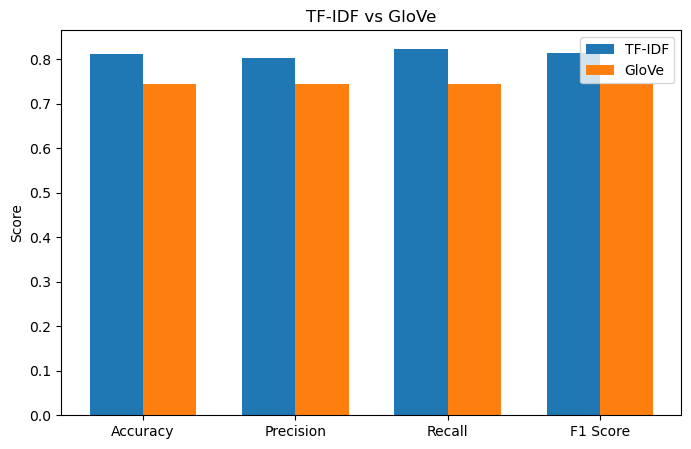

In [48]:
# Visualize the Comparison
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

tfidf_scores = [accuracy_tfidf, precision_tfidf, recall_tfidf, f1_tfidf]

glove_scores = [accuracy_glove, precision_glove, recall_glove, f1_glove]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, tfidf_scores, width, label="TF-IDF")

plt.bar(x + width/2, glove_scores, width, label="GloVe")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("TF-IDF vs GloVe")
plt.legend()
plt.show()

### 5: Contextualized vs Static Embeddings
* Objective: Compare static (Word2Vec/GloVe) and contextual embeddings (BERT/ELMo).
* Tasks:
    * Use Hugging Face Transformers to extract contextual embeddings.
    * Analyze sentence similarity or word sense disambiguation.
    * Report differences in performance/interpretability.
    

In [49]:
# Install Required Libraries
# Gensim → Word2Vec
# Transformers → BERT
# PyTorch → BERT computation
# scikit-learn → cosine similarity
!pip install gensim transformers torch scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [50]:
# Import Libraries
import numpy as np
import torch

from gensim.models import Word2Vec
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

In [51]:
# PART A — STATIC WORD2VEC
# Create a Small Corpus - We need sentences for training Word2Vec
sentences = [
    "I deposited money in the bank",
    "The bank approved my loan",
    "She went to the river bank",
    "The river bank was beautiful",
    "I love machine learning",
    "Machine learning is a part of artificial intelligence",
    "Artificial intelligence is changing technology",
    "I enjoy studying artificial intelligence"
]

# Convert each sentence into tokens:
tokenized_sentences = [
    sentence.lower().split()
    for sentence in sentences
]

print(tokenized_sentences)

[['i', 'deposited', 'money', 'in', 'the', 'bank'], ['the', 'bank', 'approved', 'my', 'loan'], ['she', 'went', 'to', 'the', 'river', 'bank'], ['the', 'river', 'bank', 'was', 'beautiful'], ['i', 'love', 'machine', 'learning'], ['machine', 'learning', 'is', 'a', 'part', 'of', 'artificial', 'intelligence'], ['artificial', 'intelligence', 'is', 'changing', 'technology'], ['i', 'enjoy', 'studying', 'artificial', 'intelligence']]


In [52]:
# Train Word2Vec
word2vec_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,  # Each word has 100 dimensions
    window=5,    # Context window
    min_count=1, # Include every word
    workers=4,   # Number of CPU workers
    sg=1         # Skip-Gram
)

In [53]:
# Get Word2Vec Embedding
bank_vector = word2vec_model.wv["bank"]

print("Word2Vec vector:")
print(bank_vector)

print("\nVector size:")
print(len(bank_vector))

Word2Vec vector:
[-5.3622725e-04  2.3643136e-04  5.1033497e-03  9.0092728e-03
 -9.3029495e-03 -7.1168090e-03  6.4588725e-03  8.9729885e-03
 -5.0154282e-03 -3.7633716e-03  7.3805046e-03 -1.5334714e-03
 -4.5366134e-03  6.5540518e-03 -4.8601604e-03 -1.8160177e-03
  2.8765798e-03  9.9187379e-04 -8.2852151e-03 -9.4488179e-03
  7.3117660e-03  5.0702621e-03  6.7576934e-03  7.6286553e-04
  6.3508903e-03 -3.4053659e-03 -9.4640139e-04  5.7685734e-03
 -7.5216377e-03 -3.9361035e-03 -7.5115822e-03 -9.3004224e-04
  9.5381187e-03 -7.3191668e-03 -2.3337686e-03 -1.9377411e-03
  8.0774371e-03 -5.9308959e-03  4.5162440e-05 -4.7537340e-03
 -9.6035507e-03  5.0072931e-03 -8.7595852e-03 -4.3918253e-03
 -3.5099984e-05 -2.9618145e-04 -7.6612402e-03  9.6147433e-03
  4.9820580e-03  9.2331432e-03 -8.1579173e-03  4.4957981e-03
 -4.1370760e-03  8.2453608e-04  8.4986202e-03 -4.4621765e-03
  4.5175003e-03 -6.7869602e-03 -3.5484887e-03  9.3985079e-03
 -1.5776526e-03  3.2137157e-04 -4.1406299e-03 -7.6826881e-03
 -1.508

In [54]:
# Create Sentence Embedding Using Word2Vec
# Word2Vec gives us word embeddings, so to represent an entire sentence we can calculate the average of its word vectors.
def word2vec_sentence_embedding(sentence):

    words = sentence.lower().split()

    vectors = []

    for word in words:

        if word in word2vec_model.wv:

            vectors.append(
                word2vec_model.wv[word]
            )

    if len(vectors) == 0:

        return np.zeros(100)

    return np.mean(vectors, axis=0)

In [55]:
# Test
sentence = "I love machine learning"

vector = word2vec_sentence_embedding(sentence)

print("Sentence vector shape:", vector.shape)

Sentence vector shape: (100,)


In [56]:
# PART B — BERT CONTEXTUAL EMBEDDINGS
# Load BERT from Hugging Face
# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

bert_model = AutoModel.from_pretrained("bert-base-uncased")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [57]:
bert_model.eval() # BERT in evaluation mode

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout): Dropout(p=

In [58]:
# Extract BERT Sentence Embedding
# BERT produces a vector for every token.
# We can use the [CLS] representation as a simple sentence embedding.
def bert_sentence_embedding(sentence):

    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():

        outputs = bert_model(**inputs)

    # CLS token embedding
    embedding = outputs.last_hidden_state[:, 0, :]

    return embedding.numpy()[0]

In [59]:
# Test
sentence = "I love machine learning"

vector = bert_sentence_embedding(sentence)

print("BERT vector shape:", vector.shape)

BERT vector shape: (768,)


In [60]:
# We got Word2Vec → 100 dimensions
# BERT → 768 dimensions

In [61]:
# Compare Sentence Similarity
sentence1 = "I love machine learning"
sentence2 = "I enjoy studying artificial intelligence"

In [62]:
# Word2Vec
vec1_w2v = word2vec_sentence_embedding(sentence1)
vec2_w2v = word2vec_sentence_embedding(sentence2)

similarity_w2v = cosine_similarity(
    [vec1_w2v],
    [vec2_w2v]
)[0][0]

print("Word2Vec Similarity:", similarity_w2v)

Word2Vec Similarity: 0.17327179


In [63]:
# BERT
vec1_bert = bert_sentence_embedding(sentence1)
vec2_bert = bert_sentence_embedding(sentence2)

similarity_bert = cosine_similarity(
    [vec1_bert],
    [vec2_bert]
)[0][0]

print("BERT Similarity:", similarity_bert)

BERT Similarity: 0.9611307


In [64]:
# Analyze Word Sense Disambiguation
sentence1 = "I deposited money in the bank."
sentence2 = "We sat near the river bank."

In [65]:
# Word2Vec
bank_vector_1 = word2vec_model.wv["bank"]
bank_vector_2 = word2vec_model.wv["bank"]

similarity = cosine_similarity(
    [bank_vector_1],
    [bank_vector_2]
)[0][0]

print("Word2Vec bank similarity:", similarity)

Word2Vec bank similarity: 1.0


In [66]:
# BERT Word Embeddings
# BERT handles this differently.
# We need to find the position of bank in each sentence.
def get_bert_token_embeddings(sentence):

    inputs = tokenizer(
        sentence,
        return_tensors="pt"
    )

    with torch.no_grad():

        outputs = bert_model(**inputs)

    tokens = tokenizer.convert_ids_to_tokens(
        inputs["input_ids"][0]
    )

    embeddings = outputs.last_hidden_state[0]

    return tokens, embeddings

In [67]:
# Use it:
sentence1 = "I deposited money in the bank."

sentence2 = "We sat near the river bank."

tokens1, embeddings1 = get_bert_token_embeddings(sentence1)
tokens2, embeddings2 = get_bert_token_embeddings(sentence2)

print(tokens1)
print(tokens2)

['[CLS]', 'i', 'deposited', 'money', 'in', 'the', 'bank', '.', '[SEP]']
['[CLS]', 'we', 'sat', 'near', 'the', 'river', 'bank', '.', '[SEP]']


In [68]:
# Find bank:
bank_index1 = tokens1.index("bank")
bank_index2 = tokens2.index("bank")

In [69]:
# Extract the contextual vectors:
bank_bert_1 = embeddings1[bank_index1].numpy()
bank_bert_2 = embeddings2[bank_index2].numpy()

In [70]:
# Calculate similarity:
bank_similarity = cosine_similarity(
    [bank_bert_1],
    [bank_bert_2]
)[0][0]

print("BERT bank similarity:", bank_similarity)

BERT bank similarity: 0.5461508


 Unlike Word2Vec, these two vectors can be different because the context is different.

In [71]:
# Better Demonstration --> Use several sentence pairs:
sentence_pairs = [
    (
        "I deposited money in the bank.",
        "I opened a savings account at the bank."
    ),

    (
        "I deposited money in the bank.",
        "We sat near the river bank."
    ),

    (
        "The dog chased the ball.",
        "The puppy ran after the ball."
    ),

    (
        "The weather is very pleasant today.",
        "The weather is beautiful today."
    ),

    (
        "I love programming.",
        "I enjoy writing code."
    )
]

In [72]:
# Calculate similarity using both methods
results = []

for s1, s2 in sentence_pairs:

    # Word2Vec
    v1_w2v = word2vec_sentence_embedding(s1)
    v2_w2v = word2vec_sentence_embedding(s2)

    sim_w2v = cosine_similarity(
        [v1_w2v],
        [v2_w2v]
    )[0][0]

    # BERT
    v1_bert = bert_sentence_embedding(s1)
    v2_bert = bert_sentence_embedding(s2)

    sim_bert = cosine_similarity(
        [v1_bert],
        [v2_bert]
    )[0][0]

    results.append({
        "Sentence 1": s1,
        "Sentence 2": s2,
        "Word2Vec Similarity": sim_w2v,
        "BERT Similarity": sim_bert
    })

In [73]:
# Create a DataFrame:
import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

                            Sentence 1  \
0       I deposited money in the bank.   
1       I deposited money in the bank.   
2             The dog chased the ball.   
3  The weather is very pleasant today.   
4                  I love programming.   

                                Sentence 2  Word2Vec Similarity  \
0  I opened a savings account at the bank.             0.499271   
1              We sat near the river bank.             0.369641   
2            The puppy ran after the ball.             1.000000   
3          The weather is beautiful today.             0.839784   
4                    I enjoy writing code.             0.455239   

   BERT Similarity  
0         0.969147  
1         0.846514  
2         0.974057  
3         0.971676  
4         0.971925  


#### Conclusion
In this experiment, static Word2Vec embeddings were compared with contextual BERT embeddings for sentence similarity. Word2Vec assigns a single vector to each word, so the representation of a word remains unchanged across different contexts. In contrast, BERT generates contextual representations in which the meaning of a word can change according to its surrounding words. The experiments demonstrate that BERT is better suited for handling context and word-sense differences, while Word2Vec is simpler, faster, and easier to interpret. Therefore, contextual embeddings provide richer representations at the cost of higher computational complexity.

| Feature                 | Word2Vec             | BERT                        |
| ----------------------- | -------------------- | --------------------------- |
| Type                    | Static               | Contextual                  |
| Representation          | One vector per word  | Vector depends on context   |
| Training                | Trained on corpus    | Pre-trained on large corpus |
| Context awareness       | Low                  | High                        |
| Word sense              | Same vector          | Different vectors           |
| Sentence representation | Average word vectors | Contextual representation   |
| Vector dimension        | 100 in our example   | 768 for BERT-base           |
| Semantic understanding  | Limited              | Stronger                    |
| Interpretability        | Relatively simple    | More complex                |
| Computational cost      | Low                  | High                        |
